In [1]:
import os
import numpy as np
import torch
from matplotlib import pyplot as plt

os.chdir("..")

In [2]:
x = np.linspace(-10, 10, num=100)

In [3]:
# x**4 - 3*x**3 + 2
y = np.log(np.power(x, 4) + np.power(x, 3) + 2)

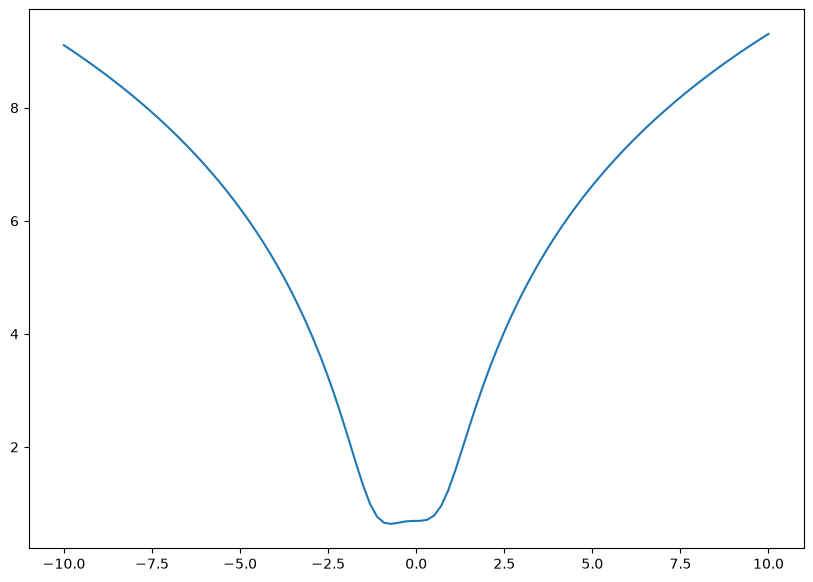

In [ ]:
plt.figure(figsize=(10, 7))
plt.plot(x, y)
# plt.savefig("./Appendix/grad_desc1.pdf")

In [5]:
def f(x):
    """A
    log(x**4 + x**3 + 2)
    """
    return np.log(np.power(x, 4) + np.power(x, 3) + 2)


def dfdx(x):
    """B
    (4*x**3 + 3*x**2) / A
    """
    return (4 * np.power(x, 3) + 3 * np.power(x, 2)) / f(x)

In [6]:
x = -9.41
lr = 0.001
epochs = 5000
for i in range(epochs):
    deriv = dfdx(x)
    x = x - lr * deriv

In [7]:
x

np.float64(-0.7500000134493898)

In [8]:
def nn(x, w1, w2):
    l1 = x @ w1  # A
    l1 = np.maximum(0, l1)  # B
    l2 = l1 @ w2
    l2 = np.maximum(0, l2)
    return l2


w1 = np.random.randn(784, 200)  # C
w2 = np.random.randn(200, 10)
x = np.random.randn(784)  # D

# A Matrix multiplication
# B Non-linear activation function
# C Weight (parameter) matrix, initialized randomly
# D Random input vector

In [9]:
nn(x, w1, w2)

array([373.57307112,   0.        ,   0.        ,   0.        ,
         0.        ,  17.85426288, 375.02096782,  58.28252735,
       339.90273424, 408.72645274])

In [10]:
def nn(x, w1, w2):
    l1 = x @ w1  # A
    l1 = torch.relu(l1)  # B
    l2 = l1 @ w2
    l2 = torch.relu(l2)
    return l2


w1 = torch.randn(784, 200, requires_grad=True)  # C
w2 = torch.randn(200, 10, requires_grad=True)
x = torch.randn(784)  # D

# A Matrix multiplication
# B Non-linear activation function
# C Weight (parameter) matrix, initialized randomly
# D Random input vector

In [11]:
nn(x, w1, w2)

tensor([  0.0000, 101.8978, 185.6260, 346.7219, 234.6327, 113.8034,   0.0000,
          0.0000,   0.0000, 375.4418], grad_fn=<ReluBackward0>)

In [12]:
import torchvision as TV


def nn(x, w1, w2):
    l1 = x @ w1  # A
    l1 = torch.relu(l1)  # B
    l2 = l1 @ w2
    return l2


w1 = torch.randn(784, 200, requires_grad=True)  # C
w2 = torch.randn(200, 10, requires_grad=True)

# A Matrix multiplication
# B Non-linear activation function
# C Weight (parameter) matrix, initialized randomly
# D Random input vector

In [13]:
try:
    mnist_data = TV.datasets.MNIST("data", train=True, download=False)  # A
except RuntimeError:
    mnist_data = TV.datasets.MNIST("data", train=True, download=True)

test_data = TV.datasets.MNIST("data", train=False, download=False)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

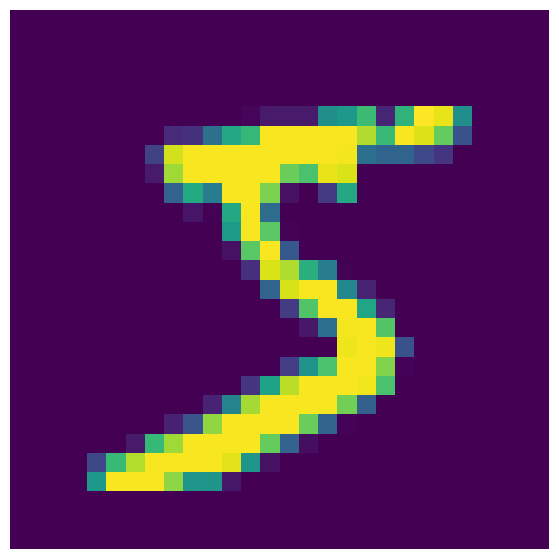

In [14]:
plt.figure(figsize=(10, 7))
plt.imshow(mnist_data.data[0])
plt.axis("off")

In [15]:
lr = 0.0001
epochs = 2500
batch_size = 1000
losses = []
lossfn = torch.nn.CrossEntropyLoss()  # B
for i in range(epochs):
    rid = np.random.randint(0, mnist_data.data.shape[0], size=batch_size)  # C
    x = mnist_data.data[rid].float().flatten(start_dim=1)  # D
    x /= x.max()  # E
    pred = nn(x, w1, w2)  # F
    target = mnist_data.targets[rid]  # G
    loss = lossfn(pred, target)  # H
    losses.append(loss)
    loss.backward()  # I
    with torch.no_grad():  # J
        w1 -= lr * w1.grad  # K
        w2 -= lr * w2.grad

# A Download and load the MNIST dataset
# B Setup a loss function
# C Get a set of random index values
# D Subset the data and flatten the 28x28 images into 784 vectors
# E Normalize the vector to be between 0 and 1
# F Make a prediction using the neural network
# G Get the ground-truth image labels
# H Compute the loss
# I Backpropagate
# J Do not compute gradients in this block
# K Gradient descent over the parameter matrices

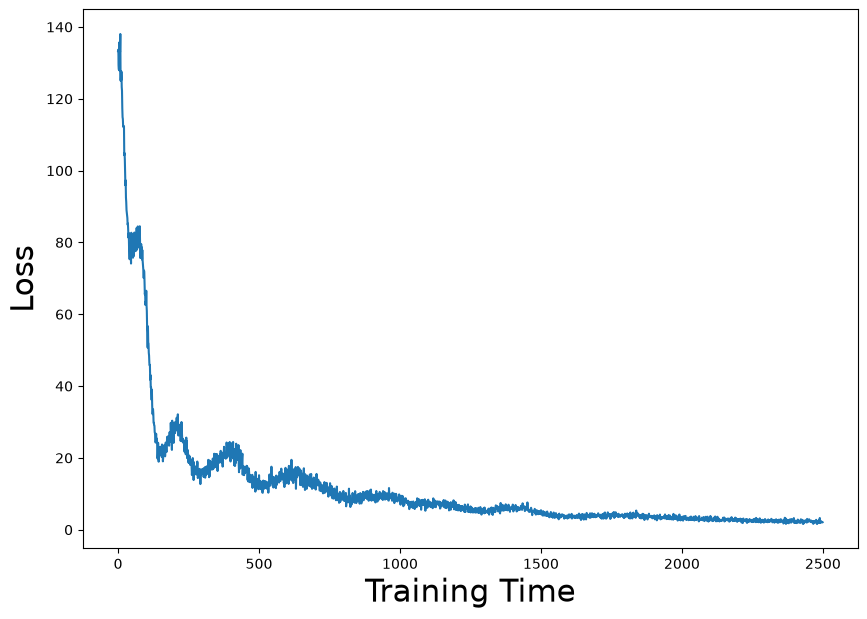

In [16]:
plt.figure(figsize=(10, 7))
plt.xlabel("Training Time", fontsize=22)
plt.ylabel("Loss", fontsize=22)
plt.plot([loss.item() for loss in losses])
# plt.savefig("./media/Appendix/loss1.png")

In [17]:
batch_size = 100
rid = np.random.randint(0, test_data.data.shape[0], size=batch_size)  # C
x = test_data.data[rid].float().flatten(start_dim=1)  # D
x /= x.max()  # E
pred = nn(x, w1, w2)  # F
pred_label = torch.log_softmax(pred, dim=1).argmax(dim=1)
target = test_data.targets[rid]  # G
num_cor = (pred_label == target).sum()

In [18]:
num_cor.float() / 100.0

tensor(0.7100)